> **Purpose:** Generated 600-tree (Kingman + birth-death) recovery: Fiedler-on-S vs Griffing-on-D vs L_sym; screens, η histograms, recovery curves, p* vs η / diameter. Generated twin of the real-data notebook.  
> **Data:** generated

# Generated-data sub-sampling recovery (the naive algorithm)

Companion to `real_data_distance_vs_similarity.ipynb` — the **same pipeline**, fed **generated**
data instead of real FASTA. Trees are simulated (**Kingman coalescent** + **birth-death**), JC
sequences are evolved on them, and $S$/$D$ are built exactly as for real data — so the
ground-truth tree is known and every step below mirrors the real-data notebook.

**Protocol**
1. $S = \text{JC\_similarity(sequences)}$; reference partition $=$ STDR split
   (`partition_taxa` on the Fiedler vector of $L(S)=\operatorname{Deg}-S$).
   Keep a tree only if its reference partition is a **valid single edge** of the generated tree.
2. On the valid trees, run the **standard bootstrap $p$-sweep**: sub-sample $S\to\hat S$, recompute
   the partition, and report **partition agreement, ARI, NMI** vs $p$.

Reuses the exact synthetic-experiment code: `bootstrap_p_sweep_simple` (`src/runners/p_sweep_inner.py`),
`compute_reference_partition_and_quality`, `check_partition_valid_in_tree`. The only thing that differs
from the real-data notebook is the data source: `make_generated` (`utils/generated_data.py`).

In [66]:
%load_ext autoreload
%autoreload 2

import os, sys
import importlib.util as _iu
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_R = Path.cwd()
while _R.parent != _R and not (_R / "setup.py").exists():
    _R = _R.parent
_root = str(_R / "sub_sampled_fielder_vec")   # sub_sampled_fielder_vec
_repo = str(_R)                               # spectral-tree-inference
for p in (_root, _repo):
    if p not in sys.path:
        sys.path.insert(0, p)
for _mod in [m for m in list(sys.modules) if m.startswith(('scripts.', 'src.'))]:
    del sys.modules[_mod]

import spectraltree
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from src.core.utils import compute_laplacian, compute_fiedler_from_laplacian, compute_normalized_laplacian
from src.utils.metrics import compute_reference_partition_and_quality
from src.utils.partition_validity import check_partition_valid_in_tree
from src.runners.p_sweep_inner import bootstrap_p_sweep_simple, _kmeans_bipartition
from src.utils.screening import run_screen
from spectraltree.spectral_tree_reconstruction import partition_taxa
from src.utils.griffing import griffing_leading_eigvec, griffing_centered
from src.utils.bpart_sweep_cache import bpart_sweep_raw

# generated-tree data loader (Kingman + birth-death) — the analogue of real-data's load_S + fasta_to_distance
from analysis.theoretical_interpretation.utils import generated_data as gd
make_generated = gd.make_generated
build_ids      = gd.build_ids

COLOR_POS, COLOR_NEG = '#d97706', '#1d4ed8'   # orange / blue (sign partition)
GEN_MARKER = {'kingman': 'o', 'bd': '^'}      # marker per generator in scatter panels
gen_of = lambda tid: tid.rsplit('_', 1)[0]

# --- experiment parameters ---
# Defaults mirror the real-data run (600 trees, n=1000). Shrink M_TAXA / SEQ_LEN / N_PER_GEN to go fast.
RUN_SWEEP      = True   # screen-only pass: count valids + eta histogram. Flip True for the p-sweep.
P_VALUES       = list(np.logspace(-2, 0, 20))   # 0.01 .. 1.0, 20 log-spaced points
BOOTSTRAP_REPS = 10
NUM_GAPS       = 10
MIN_SPLIT      = 5        # STDR/test practice; min_split=1 gives a degenerate fringe split at large n
M_TAXA         = 1000
SEQ_LEN        = 1000
N_PER_GEN      = 300      # 300 kingman + 300 bd = 600 trees, matching the real-data screen size
ETA_THR        = (M_TAXA / np.log(M_TAXA)) ** (1/3)   # recoverability threshold (Cor. imbalance) ~5.25
SCREEN_IDS     = build_ids(N_PER_GEN)

def tree_leaf_index(tree, labels):
    idx = {l: i for i, l in enumerate(labels)}
    return np.array([idx[str(l.taxon.label)] for l in tree.leaf_node_iter()])

print(f'setup ok — {len(SCREEN_IDS)} generated ids to screen ({", ".join(gd.GENERATORS)}); '
      f'm={M_TAXA}, L={SEQ_LEN}; eta threshold ~{ETA_THR:.2f}')

_load_all = lambda tid: make_generated(tid, M_TAXA, SEQ_LEN)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
setup ok — 600 generated ids to screen (kingman, bd); m=1000, L=1000; eta threshold ~5.25


## Step 1 — STDR partition of full $S$ + validity gate

Keep only trees whose full-$S$ STDR partition is a single real edge of the true tree.

In [ ]:
# Screen 1 — Fiedler-on-S (unnormalized Laplacian L=Deg(S)-S, sigma2 threshold).
valid_ids, etas_valid, rows = run_screen(
    SCREEN_IDS, _load_all,
    lambda S, D: compute_reference_partition_and_quality(
        compute_fiedler_from_laplacian(compute_laplacian(S)), S,
        num_gaps=NUM_GAPS, min_split=MIN_SPLIT)[0],
    Path('gen_screen_cache.npz'), label='Fiedler-on-S')
fiedler_valid_ids = list(valid_ids)
n_valid = len(valid_ids)
print(f'{n_valid}/{len(rows)} trees: full-S Fiedler partition is a valid single tree edge '
      f'(num_gaps={NUM_GAPS}, min_split={MIN_SPLIT})')
pd.DataFrame(rows).set_index('tree')

## Comparison mode — Fiedler-on-$S$ vs Griffing-on-$D$ vs Fiedler-on-$L_{\rm sym}$

Same validity gate, three reference operators (similarity, distance, normalised Laplacian). The Griffing screen is cached separately
(`gen_screen_griffing.npz`); the cell below loads it (or recomputes if absent).

In [ ]:
# Screen 2 — Griffing-on-D (leading eigvec of B=HDH, sign threshold tau=0).
griff_valid_ids, griff_etas, griff_rows = run_screen(
    SCREEN_IDS, _load_all,
    lambda S, D: (griffing_leading_eigvec(D) >= 0),
    Path('gen_screen_griffing.npz'), label='Griffing-on-D')
print(f'griffing-on-D: {len(griff_valid_ids)} valid   '
      f'eta min/median/max = {griff_etas.min():.1f}/{np.median(griff_etas):.1f}/{griff_etas.max():.1f}')

In [ ]:
# Screen 3 — Fiedler-on-L_sym (normalized Laplacian I-D^-1/2 S D^-1/2, sigma2 threshold).
lsym_valid_ids, lsym_etas, lsym_rows = run_screen(
    SCREEN_IDS, _load_all,
    lambda S, D: compute_reference_partition_and_quality(
        compute_fiedler_from_laplacian(compute_normalized_laplacian(S)), S,
        num_gaps=NUM_GAPS, min_split=MIN_SPLIT)[0],
    Path('gen_screen_lsym.npz'), label='L_sym')
print(f'L_sym: {len(lsym_valid_ids)}/{len(SCREEN_IDS)} valid   '
      f'eta min/median/max = {lsym_etas.min():.1f}/{np.median(lsym_etas):.1f}/{lsym_etas.max():.1f}')

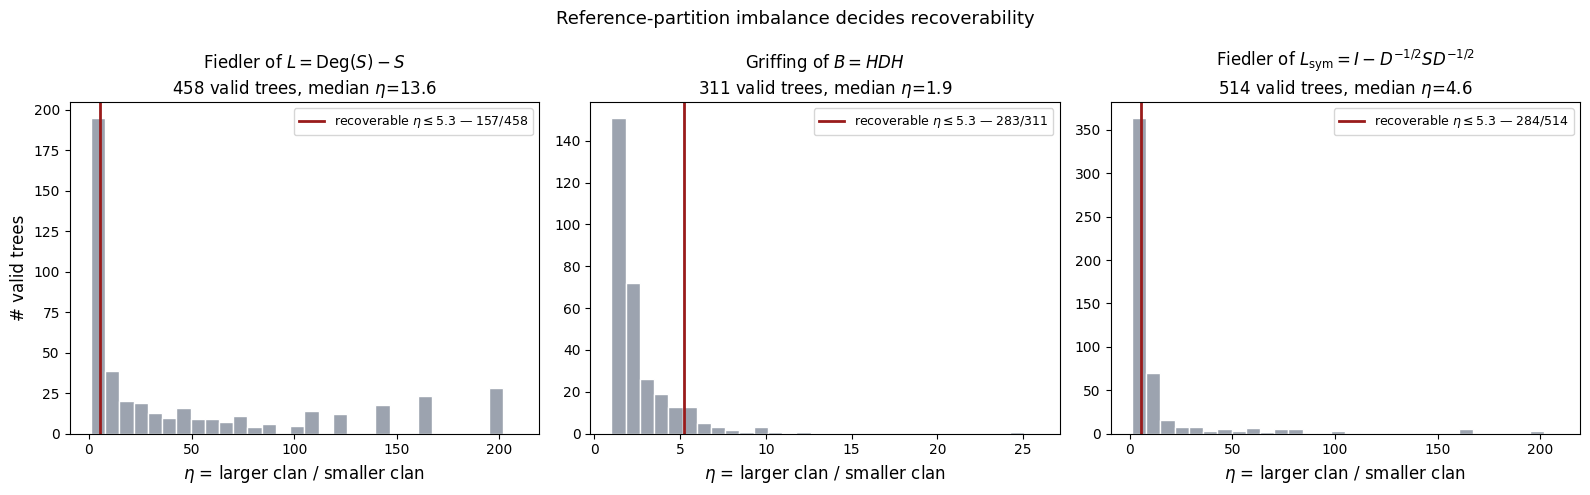

In [70]:
# side-by-side eta histograms for all three methods — each on its OWN x-range
# (a shared scale hides the Griffing / L_sym shapes). Titles give the matrix whose spectrum is used.
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
panels = [(axes[0], etas_valid, r'Fiedler of $L=\mathrm{Deg}(S)-S$'),
          (axes[1], griff_etas, r'Griffing of $B=HDH$'),
          (axes[2], lsym_etas,  r'Fiedler of $L_{\rm sym}=I-D^{-1/2}SD^{-1/2}$')]
for ax, data, name in panels:
    ax.hist(data, bins=30, range=(1, max(data.max() * 1.05, 2.0)), color='#9ca3af', edgecolor='white')
    ax.set_xlabel(r'$\eta$ = larger clan / smaller clan', fontsize=12)
    ax.set_title(f'{name}\n{len(data)} valid trees, median $\\eta$={np.median(data):.1f}', fontsize=12)
axes[0].set_ylabel('# valid trees', fontsize=12)
fig.suptitle('Reference-partition imbalance decides recoverability', fontsize=13)
fig.tight_layout(); plt.show()

### Partition imbalance by operator × threshold rule (600 Kingman trees)

How the **threshold rule** (σ₂-gap, k-means, sign τ=0) reshapes the imbalance η of the partition each operator (L, L_sym, B) picks — valid-only (the partition is a real clan).

In [12]:
# Threshold-rule sweep: 600 Kingman trees x {L, L_sym, B} x {sigma2, k-means, sign}.
# Valid-only: keep a tree's partition imbalance eta only when that partition is a real
# single-edge clan of the true tree. Cached (lightweight: just the eta arrays + counts).
KINGMAN_IDS = [f'kingman_{i:03d}' for i in range(600)]

OPERATORS = {
    'L':     lambda S, D: compute_fiedler_from_laplacian(compute_laplacian(S)),
    'L_sym': lambda S, D: compute_fiedler_from_laplacian(compute_normalized_laplacian(S)),
    'B':     lambda S, D: griffing_leading_eigvec(D),
}
THRESHOLDS = {
    '$\\sigma_2$': lambda v, S: partition_taxa(v, S, NUM_GAPS, MIN_SPLIT),
    'k-means':     lambda v, S: _kmeans_bipartition(v, MIN_SPLIT),
    'sign':        lambda v, S: (v >= 0),
}
_op_names, _thr_names = list(OPERATORS), list(THRESHOLDS)

CACHE_THR = Path('gen_threshold_eta_kingman600.npz')
_thr_meta = dict(ids=len(KINGMAN_IDS), m=M_TAXA, L=SEQ_LEN, min_split=MIN_SPLIT, num_gaps=NUM_GAPS)
thr_etas = None
if CACHE_THR.exists():
    z = np.load(CACHE_THR, allow_pickle=True)
    if dict(z['meta'].item()) == _thr_meta:
        thr_etas = {tuple(k.split('|')): np.asarray(v, float) for k, v in z['etas'].item().items()}
        print(f'loaded threshold-eta cache ({CACHE_THR})')

if thr_etas is None:
    acc = {(op, thr): [] for op in _op_names for thr in _thr_names}
    for k, tid in enumerate(KINGMAN_IDS, 1):
        S, labels, tree, D = make_generated(tid, M_TAXA, SEQ_LEN)
        sidx = tree_leaf_index(tree, labels)
        for op in _op_names:
            v = OPERATORS[op](S, D)
            for thr in _thr_names:
                try:
                    part = np.asarray(THRESHOLDS[thr](v, S)).astype(bool)
                except Exception:
                    continue
                if not bool(check_partition_valid_in_tree(tree, part[sidx])):
                    continue
                n1 = int(part.sum()); n2 = len(part) - n1
                acc[(op, thr)].append(max(n1, n2) / max(min(n1, n2), 1))
        if k % 50 == 0:
            print(f'  screened {k}/{len(KINGMAN_IDS)}')
    thr_etas = {key: np.asarray(val, float) for key, val in acc.items()}
    np.savez(CACHE_THR, meta=_thr_meta,
             etas={f'{op}|{thr}': thr_etas[(op, thr)] for op in _op_names for thr in _thr_names})
    print(f'saved threshold-eta cache ({CACHE_THR})')

# valid-count table (valid / 600 per cell)
print(f"\nvalid partitions / {len(KINGMAN_IDS)}:")
print(f"  {'op':>6} | " + " | ".join(f'{t:>8}' for t in _thr_names))
for op in _op_names:
    print(f"  {op:>6} | " + " | ".join(f'{len(thr_etas[(op, t)]):>8d}' for t in _thr_names))

loaded threshold-eta cache (gen_threshold_eta_kingman600.npz)

valid partitions / 600:
      op | $\sigma_2$ |  k-means |     sign
       L |      350 |      595 |      591
   L_sym |      459 |      599 |      580
       B |      483 |      597 |      576


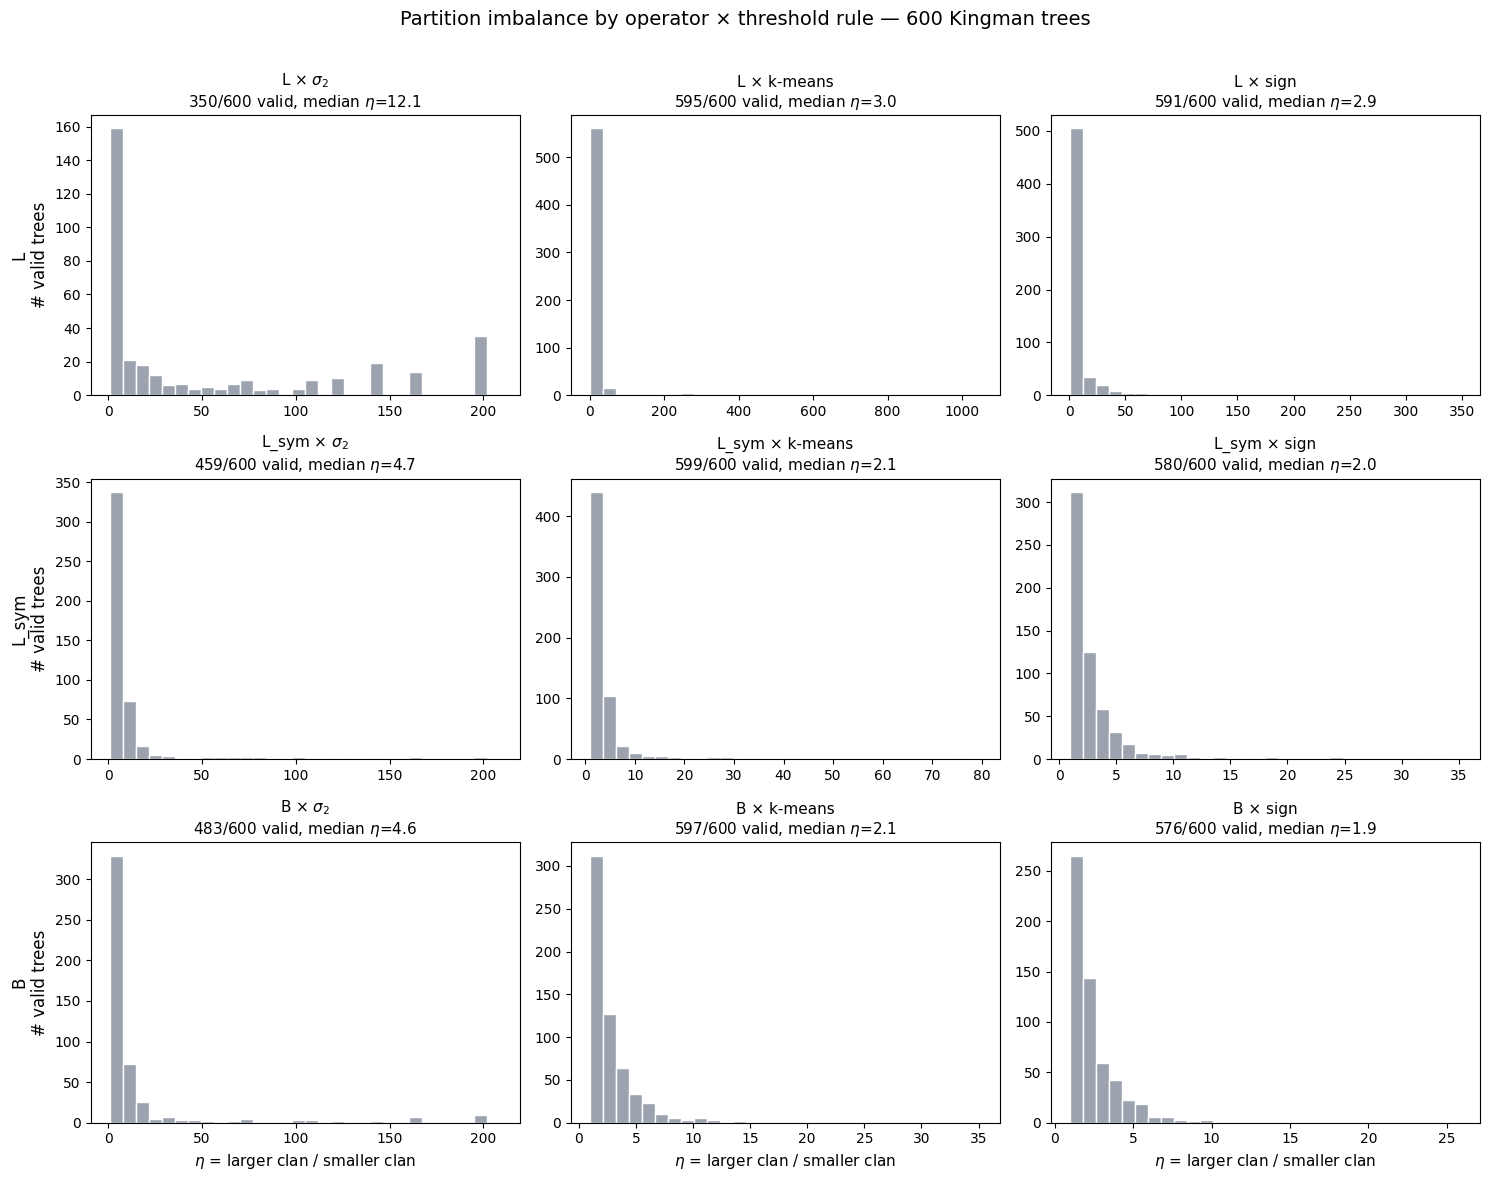

In [13]:
# 3x3 histogram grid: rows = operator (L, L_sym, B), cols = threshold (sigma2, k-means, sign).
# Valid-only partition imbalance eta; each panel on its OWN x-range.
fig, axes = plt.subplots(len(_op_names), len(_thr_names), figsize=(15, 12))
for r, op in enumerate(_op_names):
    for c, thr in enumerate(_thr_names):
        ax = axes[r, c]
        data = np.asarray(thr_etas[(op, thr)], float)
        if data.size:
            ax.hist(data, bins=30, range=(1, max(data.max() * 1.05, 2.0)),
                    color='#9ca3af', edgecolor='white')
            med = np.median(data)
        else:
            med = float('nan')
        ax.set_title(f'{op} × {thr}\n{data.size}/{len(KINGMAN_IDS)} valid, median $\\eta$={med:.1f}',
                     fontsize=11)
        if r == len(_op_names) - 1:
            ax.set_xlabel(r'$\eta$ = larger clan / smaller clan', fontsize=11)
        if c == 0:
            ax.set_ylabel(f'{op}\n# valid trees', fontsize=12)
fig.suptitle('Partition imbalance by operator × threshold rule — 600 Kingman trees', fontsize=14)
fig.tight_layout(rect=(0, 0, 1, 0.97)); plt.show()

#### Ranked bars (high → low): median $\eta$ with 95% CI, and # valid partitions

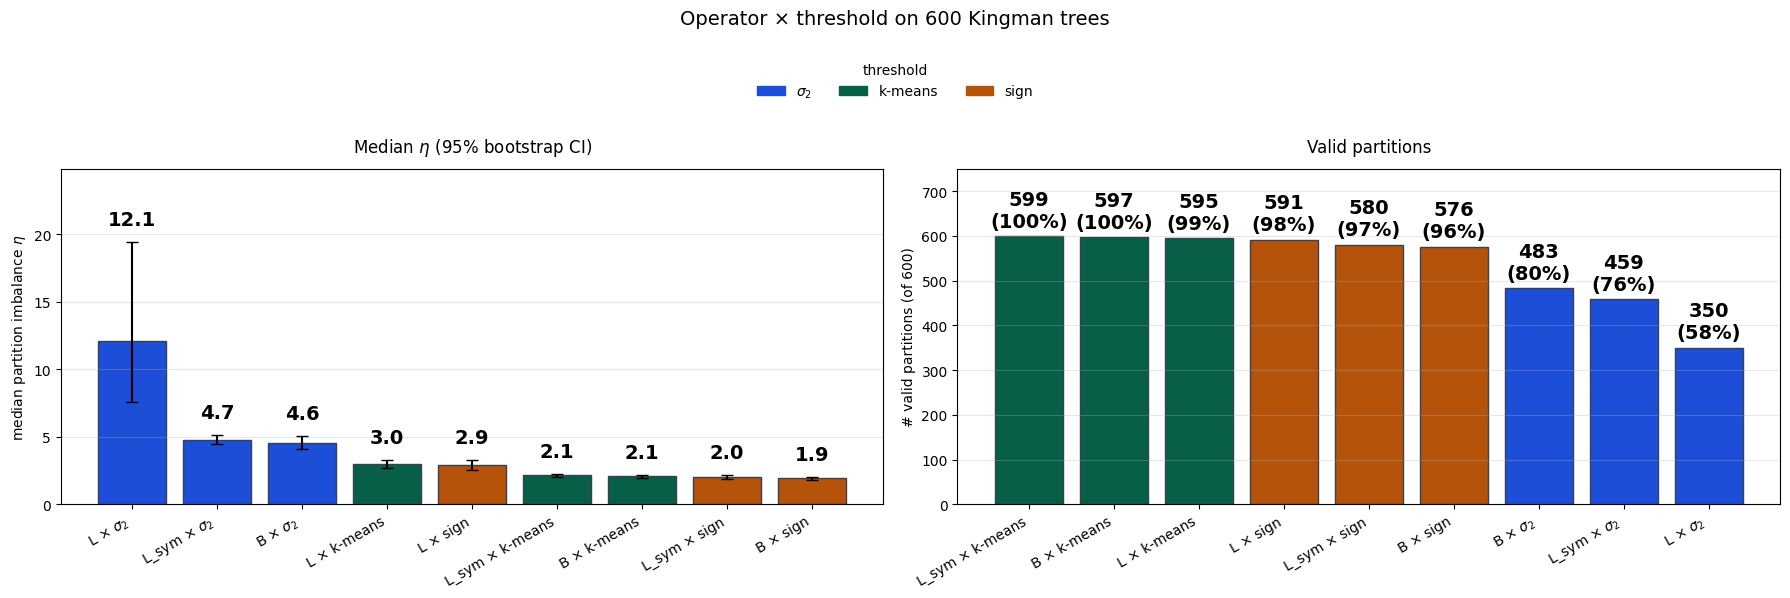

In [14]:
# Two barplots side by side: (left) median eta with 95% bootstrap CI; (right) # valid partitions.
# Both over the 600 Kingman trees, sorted high -> low independently, colored by threshold rule.
from matplotlib.patches import Patch

_rng_ci = np.random.default_rng(0)
def _median_ci(x, n_boot=2000, alpha=0.05):
    x = np.asarray(x, float)
    if x.size == 0:
        return np.nan, np.nan, np.nan
    med = float(np.median(x))
    if x.size == 1:
        return med, med, med
    boots = np.median(_rng_ci.choice(x, size=(n_boot, x.size), replace=True), axis=1)
    lo, hi = np.percentile(boots, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return med, float(lo), float(hi)

THR_COLOR = {_thr_names[0]: '#1d4ed8', _thr_names[1]: '#065f46', _thr_names[2]: '#b45309'}
_n_total = len(KINGMAN_IDS)
recs = []
for op in _op_names:
    for thr in _thr_names:
        x = thr_etas[(op, thr)]
        med, lo, hi = _median_ci(x)
        recs.append({'lab': f'{op} × {thr}', 'thr': thr, 'med': med, 'lo': lo, 'hi': hi, 'k': len(x)})

fig, (axL, axR) = plt.subplots(1, 2, figsize=(18, 6))

# LEFT — median eta (95% CI), high -> low
sL = sorted([r for r in recs if np.isfinite(r['med'])], key=lambda r: r['med'], reverse=True)
xL = np.arange(len(sL))
medsL = np.array([r['med'] for r in sL]); losL = np.array([r['lo'] for r in sL]); hisL = np.array([r['hi'] for r in sL])
axL.bar(xL, medsL, yerr=np.vstack([medsL - losL, hisL - medsL]), capsize=4,
        color=[THR_COLOR[r['thr']] for r in sL], edgecolor='#374151')
_padL = 0.05 * float(hisL.max())
for xi, r in zip(xL, sL):
    axL.text(xi, r['hi'] + _padL, f"{r['med']:.1f}", ha='center', va='bottom',
             fontsize=14, fontweight='bold')
axL.set_ylim(0, float(hisL.max()) * 1.28)
axL.set_xticks(xL); axL.set_xticklabels([r['lab'] for r in sL], rotation=30, ha='right')
axL.set_ylabel(r'median partition imbalance $\eta$')
axL.set_title('Median $\\eta$ (95% bootstrap CI)', pad=12)
axL.grid(True, axis='y', alpha=0.3)

# RIGHT — # valid partitions, high -> low
sR = sorted(recs, key=lambda r: r['k'], reverse=True)
xR = np.arange(len(sR))
ksR = np.array([r['k'] for r in sR])
axR.bar(xR, ksR, color=[THR_COLOR[r['thr']] for r in sR], edgecolor='#374151')
_padR = 0.02 * _n_total
for xi, r in zip(xR, sR):
    axR.text(xi, r['k'] + _padR, f"{r['k']}\n({100 * r['k'] / _n_total:.0f}%)",
             ha='center', va='bottom', fontsize=14, fontweight='bold')
axR.set_ylim(0, _n_total * 1.25)
axR.set_xticks(xR); axR.set_xticklabels([r['lab'] for r in sR], rotation=30, ha='right')
axR.set_ylabel(f'# valid partitions (of {_n_total})')
axR.set_title('Valid partitions', pad=12)
axR.grid(True, axis='y', alpha=0.3)

fig.legend(handles=[Patch(color=THR_COLOR[t], label=t) for t in _thr_names],
           title='threshold', loc='upper center', bbox_to_anchor=(0.5, 0.92), ncol=3, frameon=False)
fig.suptitle('Operator × threshold on 600 Kingman trees', fontsize=14, y=0.99)
fig.tight_layout(rect=(0, 0, 1, 0.86)); plt.show()

### Which trees does each method pick a valid partition on? *(no sub-sampling)*

Before discussing how robust each method is **under sub-sampling**, the prior question is
*partition choice on the full data*. The cells below cross-tabulate the three methods
(Fiedler-on-$S$, Griffing-on-$D$, Fiedler-on-$L_{\rm sym}$) over the screened trees:

- **P1** — validity **agreement matrix** across all three methods (which trees each validates, where they overlap).
- **P2** — joint scatter of $\eta_S$ vs $\eta_D$, one point per tree, colored by validity status.
- **P3** — the same 2×2, broken down by $\eta_S$ bucket — does $D$ rescue the high-$\eta_S$ trees where $S$ snips a degenerate fringe?
- **P4** — on the both-valid cohort, do the two methods pick the *same* partition (ARI / NMI), or different ones?

`both_valid_ids` (set by P1) is exported for use by the downstream recovery cell.

pairwise both-valid overlap (diagonal = total valid per method):
               Fiedler-$S$  Griffing-$D$  $L_{\rm sym}$
Fiedler-$S$            458           199            401
Griffing-$D$           199           311            240
$L_{\rm sym}$          401           240            514

valid in all THREE methods: 154
valid in at least one:      597 / 600


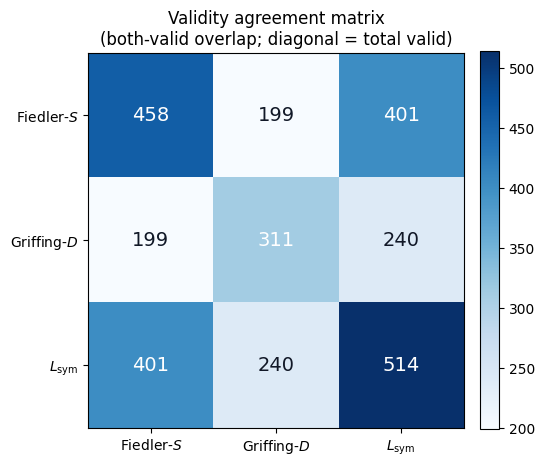


cohort used by every downstream P*/recovery panel: 199 trees valid in both Fiedler-$S$ and Griffing-$D$
  only-S: 259   only-D: 112   neither: 30


In [15]:
# P1 — validity agreement across ALL THREE methods over the full screen.
# Pure set arithmetic on the screen results: which trees does each method validate, and where do they overlap?
S_set = set(fiedler_valid_ids); D_set = set(griff_valid_ids); L_set = set(lsym_valid_ids)
N_TOTAL = len(SCREEN_IDS)

# downstream cohorts (S vs D) — consumed by the P2 / P4 / demo / recovery cells below
both_valid_ids = sorted(S_set & D_set)
only_S_ids     = sorted(S_set - D_set)
only_D_ids     = sorted(D_set - S_set)
neither_count  = N_TOTAL - len(S_set | D_set)

# 3x3 agreement matrix: diagonal = #valid for that method; (i, j) = #trees valid in BOTH i and j
methods = [('Fiedler-$S$', S_set), ('Griffing-$D$', D_set), ('$L_{\\rm sym}$', L_set)]
names = [m for m, _ in methods]
M = np.array([[len(si & sj) for _, sj in methods] for _, si in methods])
print('pairwise both-valid overlap (diagonal = total valid per method):')
print(pd.DataFrame(M, index=names, columns=names))
print(f'\nvalid in all THREE methods: {len(S_set & D_set & L_set)}')
print(f'valid in at least one:      {len(S_set | D_set | L_set)} / {N_TOTAL}')

# annotated heatmap of the agreement matrix
fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(M, cmap='Blues')
ax.set_xticks(range(3)); ax.set_xticklabels(names)
ax.set_yticks(range(3)); ax.set_yticklabels(names)
_thr = M.max() * 0.5 if M.max() else 1
for i in range(3):
    for j in range(3):
        ax.text(j, i, str(M[i, j]), ha='center', va='center', fontsize=14,
                color='white' if M[i, j] > _thr else '#111827')
ax.set_title('Validity agreement matrix\n(both-valid overlap; diagonal = total valid)', fontsize=12)
fig.colorbar(im, fraction=0.046, pad=0.04); fig.tight_layout(); plt.show()

print(f'\ncohort used by every downstream P*/recovery panel: '
      f'{len(both_valid_ids)} trees valid in both Fiedler-$S$ and Griffing-$D$')
print(f'  only-S: {len(only_S_ids)}   only-D: {len(only_D_ids)}   neither: {neither_count}')

### One tree, three partitions

Patristic tree + a solid 2-color sign strip per operator (one demo tree valid in **both** methods,
nearest the Griffing median $\eta$). Fiedler-on-$S$ snips a tiny fringe; Griffing-on-$D$ cuts the deep
balanced divide; Fiedler-of-$L(D)$ shown for contrast.

demo tree bd_126  (valid in both; griffing eta=1.87);  199 trees valid in both


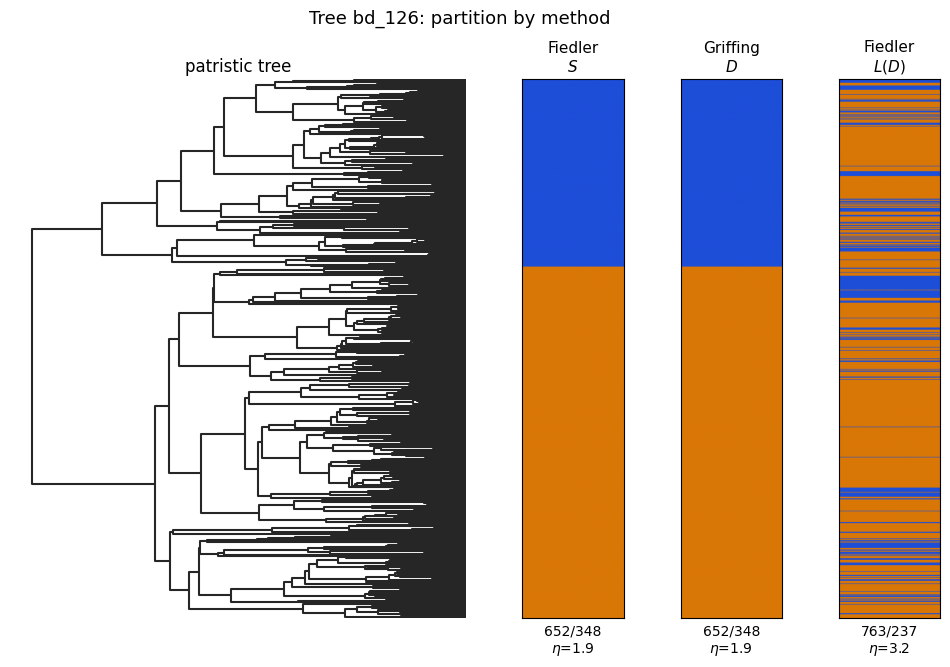

In [17]:
def patristic_distance_matrix(tree):
    leaf_taxa = [leaf.taxon for leaf in tree.leaf_node_iter()]
    n = len(leaf_taxa)
    pdm = tree.phylogenetic_distance_matrix()
    Dp = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            d = pdm.distance(leaf_taxa[i], leaf_taxa[j])
            Dp[i, j] = Dp[j, i] = d
    return Dp

def sign_orient(v):
    s = (np.asarray(v) >= 0).astype(int)
    if s.sum() < len(s) - s.sum():   # make the majority side = 1 (orange) for consistent coloring
        s = 1 - s
    return s

# pick one tree valid in BOTH methods, nearest the griffing-median eta
_fset = set(fiedler_valid_ids)
both  = [t for t in griff_valid_ids if t in _fset]
_gmap = {t: e for t, e in zip(griff_valid_ids, griff_etas)}
_med  = np.median([_gmap[t] for t in both])
tid   = min(both, key=lambda t: abs(_gmap[t] - _med))
print(f'demo tree {tid}  (valid in both; griffing eta={_gmap[tid]:.2f});  {len(both)} trees valid in both')

S, labels, tree, D = make_generated(tid, M_TAXA, SEQ_LEN)
vS  = compute_fiedler_from_laplacian(compute_laplacian(S))     # labels order
vGD = griffing_leading_eigvec(D)                               # labels order
vFD = compute_fiedler_from_laplacian(compute_laplacian(D))     # labels order

to_tree = tree_leaf_index(tree, labels)
strips = [('Fiedler\n$S$',    sign_orient(vS[to_tree])),
          ('Griffing\n$D$',   sign_orient(vGD[to_tree])),
          ('Fiedler\n$L(D)$', sign_orient(vFD[to_tree]))]

Dpat = patristic_distance_matrix(tree)
Z = hierarchy.linkage(squareform(Dpat, checks=False), method='average')

fig = plt.figure(figsize=(12, 7))
gs = fig.add_gridspec(1, 4, width_ratios=[4.5, 1, 1, 1], wspace=0.30)
ax_tree = fig.add_subplot(gs[0, 0])
dendro = hierarchy.dendrogram(Z, ax=ax_tree, orientation='left', no_labels=True,
                              color_threshold=0, above_threshold_color='#262626')
leaf_order = dendro['leaves']
ax_tree.set_title('patristic tree', fontsize=12)
ax_tree.set_xticks([]); ax_tree.set_yticks([])
for sp in ax_tree.spines.values(): sp.set_visible(False)

cmap = ListedColormap([COLOR_NEG, COLOR_POS])
for j, (name, sgn) in enumerate(strips, start=1):
    ax = fig.add_subplot(gs[0, j])
    ax.imshow(sgn[leaf_order][:, None], aspect='auto', cmap=cmap, vmin=0, vmax=1, origin='lower')
    n1 = int(sgn.sum()); n2 = len(sgn) - n1
    eta = max(n1, n2) / max(min(n1, n2), 1)
    ax.set_title(name, fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlabel(f'{max(n1,n2)}/{min(n1,n2)}\n$\\eta$={eta:.1f}', fontsize=10)
fig.suptitle(f"Tree {tid}: partition by method", fontsize=13)
plt.show()

### What each operator sees — raw inputs vs operators

Same demo tree, rows/cols sorted by the Griffing axis. **Row 1 — raw inputs $S$, $D$.**
**Row 2 — operators $L=\mathrm{Deg}(S)-S$ (Fiedler), $B=HDH$ (Griffing), and
$L_{\rm sym}=I-D^{-1/2}SD^{-1/2}$ (normalised Fiedler).**
Each panel uses its **own** color scale (no shared range), so each operator's structure is visible on its
own terms. Operator panels use a diverging yellow-centered map so $0$ is visible — $L$ is structureless
(degenerate cut) while $B$ and $L_{\rm sym}$ show the $\pm$ block structure of a stable bimodal split.

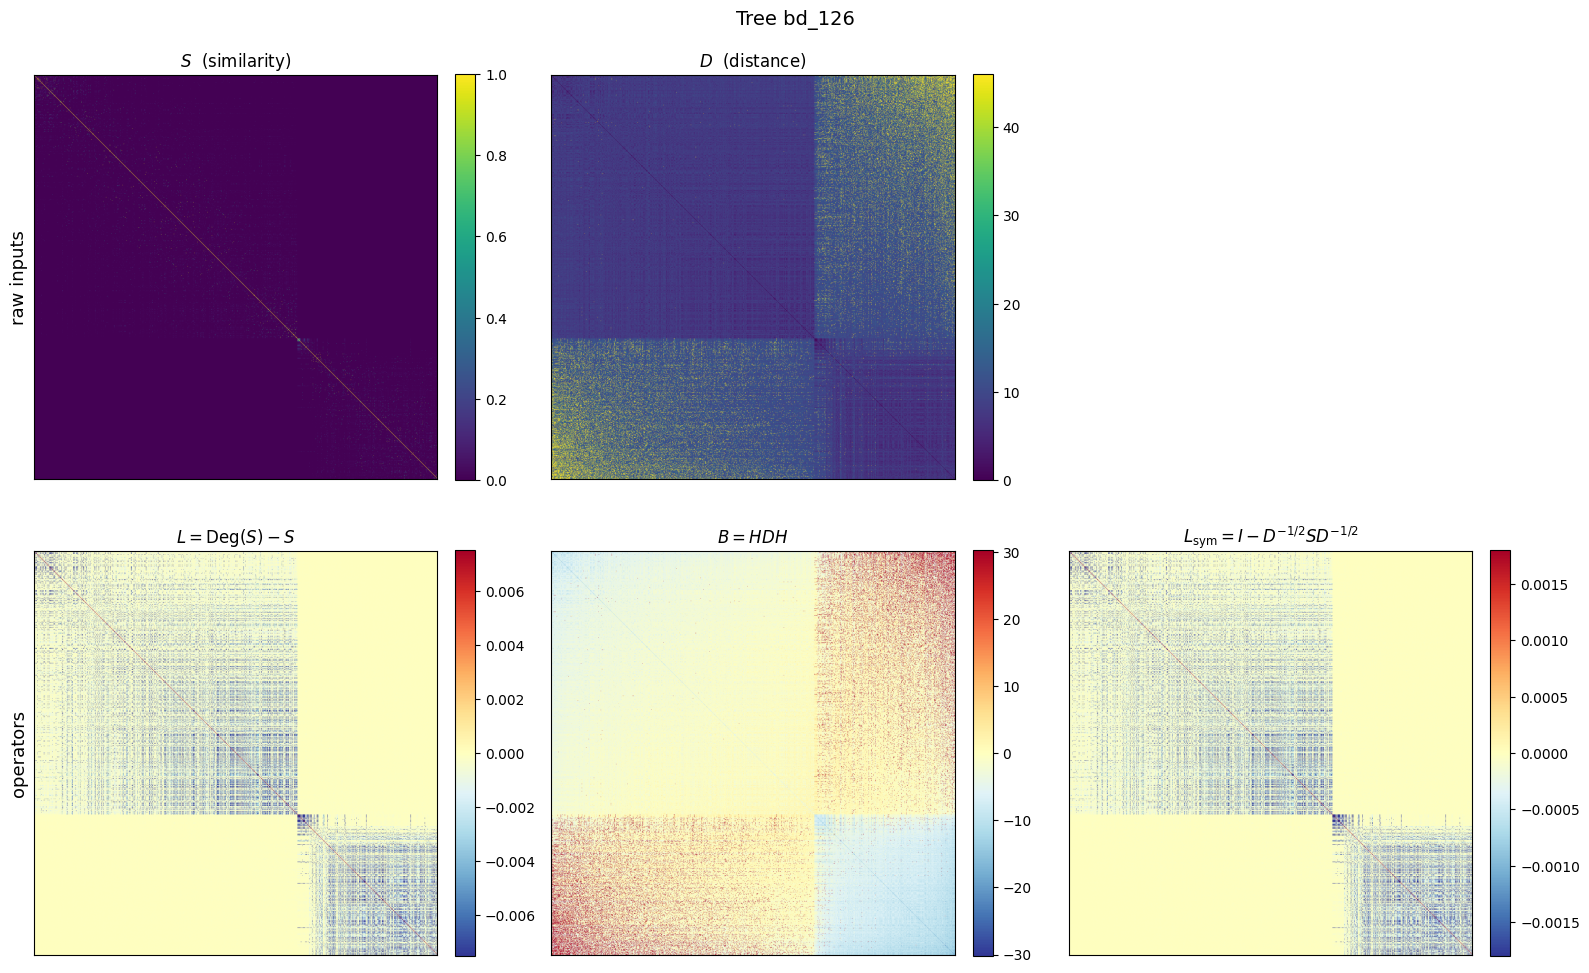

In [18]:
S_m, labels_m, _t_m, D_m = make_generated(tid, M_TAXA, SEQ_LEN)   # tid = the demo tree above
L_m = compute_laplacian(S_m)
B_m = griffing_centered(D_m)
# symmetric normalised Laplacian  L_sym = I - D^{-1/2} S D^{-1/2}   (D = degree matrix of S)
_deg = np.asarray(S_m.sum(axis=1)).ravel()
_dis = 1.0 / np.sqrt(np.maximum(_deg, 1e-12))
Lsym_m = np.eye(len(_deg)) - (S_m * _dis[:, None]) * _dis[None, :]
Lsym_m = 0.5 * (Lsym_m + Lsym_m.T)

order = np.argsort(griffing_leading_eigvec(D_m))   # sort taxa along the Griffing axis
_ro = lambda M: M[order][:, order]
Sr, Dr, Lr, Br, LSr = _ro(S_m), _ro(D_m), _ro(L_m), _ro(B_m), _ro(Lsym_m)

# Each panel keeps its OWN scale (no shared range). Raw inputs: sequential viridis.
# Operators: diverging RdYlBu_r centered at 0, per-matrix range from its own off-diagonal spread.
DIV = 'RdYlBu_r'
def _sym_range(M):
    off = M[~np.eye(M.shape[0], dtype=bool)]
    return float(np.percentile(np.abs(off), 95)) or 1.0

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, Mx, ttl in [(axes[0, 0], Sr, r'$S$  (similarity)'),
                    (axes[0, 1], Dr, r'$D$  (distance)')]:
    im = ax.imshow(Mx, cmap='viridis')
    ax.set_title(ttl, fontsize=12); fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
axes[0, 2].axis('off')

for ax, Mx, ttl in [(axes[1, 0], Lr,  r'$L=\mathrm{Deg}(S)-S$'),
                    (axes[1, 1], Br,  r'$B=HDH$'),
                    (axes[1, 2], LSr, r'$L_{\rm sym}=I-D^{-1/2}SD^{-1/2}$')]:
    v = _sym_range(Mx)
    im = ax.imshow(Mx, cmap=DIV, vmin=-v, vmax=v)
    ax.set_title(ttl, fontsize=12); fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
axes[0, 0].set_ylabel('raw inputs', fontsize=13)
axes[1, 0].set_ylabel('operators', fontsize=13)
fig.suptitle(f"Tree {tid}", fontsize=14)
fig.tight_layout(); plt.show()

### Recovery curve — similarity vs distance vs normalised

Median NMI vs $p$ over the trees valid in **both** Fiedler-$S$ and Griffing-$D$ (up to 100), with
**all three** operators — $L=\mathrm{Deg}(S)-S$ (similarity), $B=HDH$ (distance), and
$L_{\rm sym}=I-D^{-1/2}SD^{-1/2}$ (normalised) — each recovering its own full-matrix reference.

loaded recovery sweeps from cache


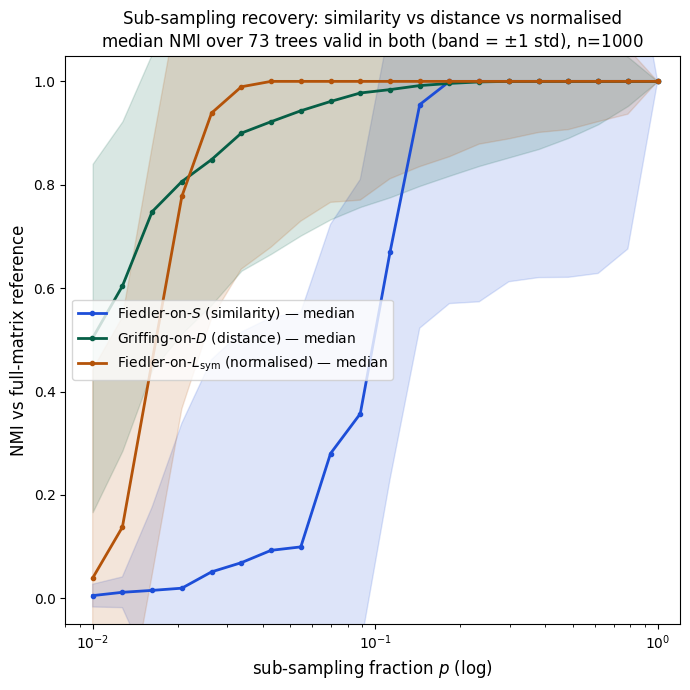

In [19]:
import scipy.linalg
from sklearn.metrics import normalized_mutual_info_score
from src.runners.p_sweep_inner import _subsample_matrix_entries

def _fast_fiedler_Lsym(M):
    deg = np.asarray(M.sum(axis=1)).ravel()
    dis = 1.0 / np.sqrt(np.maximum(deg, 1e-12))
    Lsym = np.eye(len(deg)) - (M * dis[:, None]) * dis[None, :]
    Lsym = 0.5 * (Lsym + Lsym.T)
    _, vecs = scipy.linalg.eigh(Lsym, subset_by_index=[0, 1])
    return vecs[:, 1]

def _lsym_sweep_one_tree(S, fr_ref, pr_ref, p_values, reps, seed_base):
    pr_int = np.asarray(pr_ref).astype(int); nmi = []
    for p_idx, p in enumerate(p_values):
        if p >= 0.9999:
            nmi.append(1.0); continue
        aligned = []
        for r in range(reps):
            S_hat = _subsample_matrix_entries(S, p, seed=seed_base + 10_000 * p_idx + r, builder=None)
            try:
                f_est = _fast_fiedler_Lsym(S_hat)
            except Exception:
                continue
            if np.dot(f_est, fr_ref) < 0:
                f_est = -f_est
            aligned.append(f_est)
        if not aligned:
            nmi.append(float('nan')); continue
        v_avg = np.mean(aligned, axis=0)
        nmi.append(float(normalized_mutual_info_score(pr_int, (v_avg > 0).astype(int))))
    return np.asarray(nmi, float)

# cohort = trees valid in BOTH methods, balanced across generators so both are represented.
N_COMPARE, REPS = 100, BOOTSTRAP_REPS
CMP      = Path('gen_compare_sweep.npz')
CMP_LSYM = Path('gen_compare_sweep_lsym.npz')
_pvc = np.round(P_VALUES, 6)
_both_all = [t for t in griff_valid_ids if t in set(fiedler_valid_ids)]
_per_gen = max(1, N_COMPARE // max(1, len(gd.GENERATORS)))
cohort = sorted(sum([sorted([t for t in _both_all if gen_of(t) == g])[:_per_gen]
                     for g in gd.GENERATORS], []))

def _cache_ok(path, key):
    if not path.exists():
        return None
    z = np.load(path, allow_pickle=True)
    if list(np.round(z['p_values'], 6)) == list(_pvc) and list(z['tree_ids']) == cohort:
        return z[key]
    return None

nmi_S = _cache_ok(CMP, 'nmi_S'); nmi_G = _cache_ok(CMP, 'nmi_G'); nmi_LS = _cache_ok(CMP_LSYM, 'nmi_LS')
need_SG = nmi_S is None or nmi_G is None
need_LS = nmi_LS is None
if not (need_SG or need_LS):
    print('loaded recovery sweeps from cache')

if need_SG or need_LS:
    print(f'computing recovery sweep: {len(cohort)} trees x {len(P_VALUES)} p x {REPS} reps '
          f'(S/G={need_SG}, L_sym={need_LS})...')
    _S, _G, _LS = [], [], []
    for ti, tid in enumerate(cohort):
        S, labels, tree, D = make_generated(tid, M_TAXA, SEQ_LEN)
        fr = compute_fiedler_from_laplacian(compute_laplacian(S))
        pr, _, _ = compute_reference_partition_and_quality(fr, S, num_gaps=NUM_GAPS, min_split=MIN_SPLIT)
        if need_SG:
            out = bootstrap_p_sweep_simple(S, fr, P_VALUES, bootstrap_reps=REPS, seed=1000 * ti,
                                           num_gaps=NUM_GAPS, min_split=MIN_SPLIT,
                                           partition_ref=pr, partition_method='sigma2')
            _S.append(np.asarray(out['partition_nmi_M'], float))
            raw = bpart_sweep_raw(D, P_VALUES, reps=REPS, seed_base=1000 * ti)
            _G.append(np.array([float(np.mean(pp['nmi'])) for pp in raw['per_p']]))
        if need_LS:
            fr_LS = _fast_fiedler_Lsym(S); pr_LS = (fr_LS > 0).astype(int)
            _LS.append(_lsym_sweep_one_tree(S, fr_LS, pr_LS, P_VALUES, REPS, seed_base=1000 * ti + 7777))
        if (ti + 1) % 5 == 0:
            print(f'  swept {ti+1}/{len(cohort)}')
    if need_SG:
        nmi_S = np.vstack(_S); nmi_G = np.vstack(_G)
        np.savez(CMP, p_values=_pvc, tree_ids=np.array(cohort, dtype=object), nmi_S=nmi_S, nmi_G=nmi_G)
    if need_LS:
        nmi_LS = np.vstack(_LS)
        np.savez(CMP_LSYM, p_values=_pvc, tree_ids=np.array(cohort, dtype=object), nmi_LS=nmi_LS)
    print('saved recovery caches')

P = np.asarray(_pvc, float)
nt = nmi_S.shape[0]
fig, ax = plt.subplots(figsize=(7, 7))
for data, name, col in [(nmi_S,  'Fiedler-on-$S$ (similarity)',          '#1d4ed8'),
                        (nmi_G,  'Griffing-on-$D$ (distance)',           '#065f46'),
                        (nmi_LS, 'Fiedler-on-$L_{\\rm sym}$ (normalised)', '#b45309')]:
    med = np.nanmedian(data, 0); sd = np.nanstd(data, 0)
    ax.plot(P, med, color=col, lw=2, marker='o', ms=3, label=f'{name} — median')
    ax.fill_between(P, med - sd, med + sd, color=col, alpha=0.15)
ax.set_xscale('log')
ax.set_xlabel('sub-sampling fraction $p$ (log)', fontsize=12)
ax.set_ylabel('NMI vs full-matrix reference', fontsize=12)
ax.set_title(f'Sub-sampling recovery: similarity vs distance vs normalised\n'
             f'median NMI over {nt} trees valid in both (band = $\\pm$1 std), n={M_TAXA}', fontsize=12)
ax.set_xlim(P.min() * 0.8, 1.2); ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=10, loc='center left')
fig.tight_layout(); plt.show()

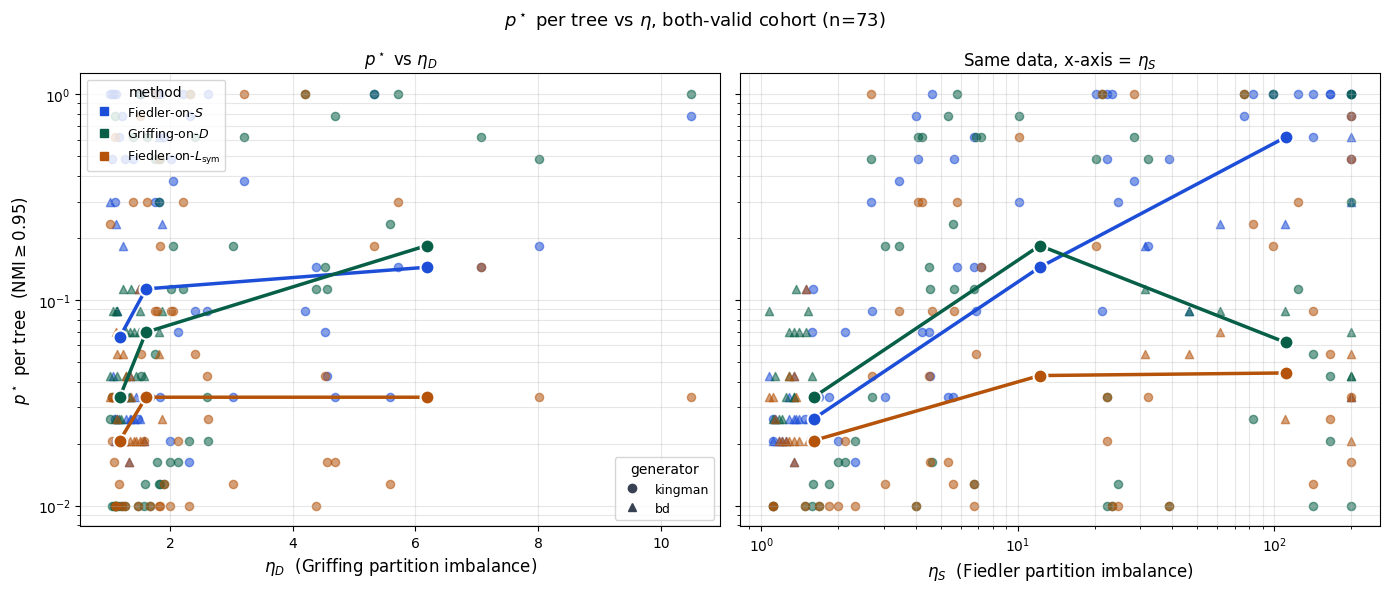

In [20]:
# p* vs eta (per-tree) — all three methods. color = method (blue=S, green=D, amber=L_sym);
# marker = generator (o=kingman, ^=bd).
def p_star_per_tree(nmi_arr, p_values, thresh=0.95):
    out = []
    for row in np.asarray(nmi_arr, float):
        ok = np.where(row >= thresh)[0]
        out.append(float(p_values[ok[0]]) if ok.size else np.inf)
    return np.array(out)

P_arr    = np.asarray(_pvc, float)
pstar_S  = p_star_per_tree(nmi_S,  P_arr)
pstar_G  = p_star_per_tree(nmi_G,  P_arr)
pstar_LS = p_star_per_tree(nmi_LS, P_arr)

eta_D_per_cohort = np.array([eta_D_map[t] for t in cohort])
eta_S_per_cohort = np.array([eta_S_map[t] for t in cohort])
gen_per_cohort   = np.array([gen_of(t) for t in cohort])

METHODS = [(pstar_S,  '#1d4ed8', 'Fiedler-on-$S$'),
           (pstar_G,  '#065f46', 'Griffing-on-$D$'),
           (pstar_LS, '#b45309', 'Fiedler-on-$L_{\\rm sym}$')]

def _scatter_by_gen(ax, x, y, base_mask, col):
    for g, mk in GEN_MARKER.items():
        m = base_mask & (gen_per_cohort == g)
        ax.scatter(x[m], y[m], color=col, marker=mk, alpha=0.55, s=35)

def _panel(ax, x):
    for ps, col, _ in METHODS:
        _scatter_by_gen(ax, x, ps, np.isfinite(ps) & (ps > 0), col)
    edges = np.quantile(x, [0, 1/3, 2/3, 1.0]); centers = 0.5 * (edges[:-1] + edges[1:])
    for ps, col, _ in METHODS:
        m = np.isfinite(ps) & (ps > 0)
        meds = [np.median(ps[m & (x >= lo) & (x <= hi)]) if (m & (x >= lo) & (x <= hi)).any() else np.nan
                for lo, hi in zip(edges[:-1], edges[1:])]
        ax.plot(centers, meds, color=col, lw=2.5, marker='o', ms=10, mec='white', mew=1.5)
    ax.set_yscale('log'); ax.grid(True, alpha=0.3, which='both')

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
_panel(a1, eta_D_per_cohort)
a1.set_xlabel(r'$\eta_D$  (Griffing partition imbalance)', fontsize=12)
a1.set_ylabel(r'$p^\star$ per tree  (NMI$\geq 0.95$)', fontsize=12)
a1.set_title(r'$p^\star$ vs $\eta_D$')
_mh = [Line2D([0], [0], marker='s', ls='', color=col, label=lbl) for _, col, lbl in METHODS]
_gh = [Line2D([0], [0], marker=m, ls='', color='#374151', label=g) for g, m in GEN_MARKER.items()]
_l1 = a1.legend(handles=_mh, fontsize=9, loc='upper left', title='method'); a1.add_artist(_l1)
a1.legend(handles=_gh, fontsize=9, loc='lower right', title='generator')
_panel(a2, eta_S_per_cohort); a2.set_xscale('log')
a2.set_xlabel(r'$\eta_S$  (Fiedler partition imbalance)', fontsize=12)
a2.set_title(r'Same data, x-axis = $\eta_S$')
fig.suptitle(f'$p^\\star$ per tree vs $\\eta$, both-valid cohort (n={len(cohort)})', fontsize=13)
fig.tight_layout(); plt.show()

loaded gen_rT_cohort.npz


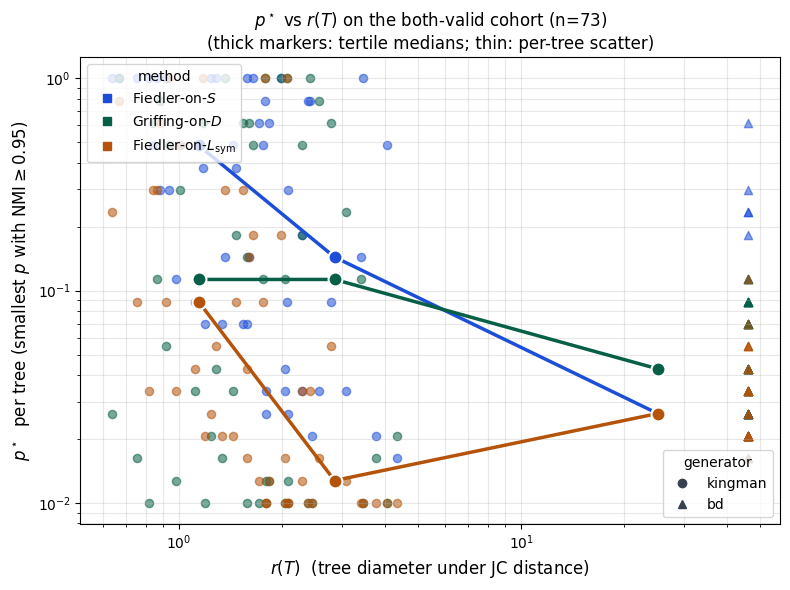

r(T) range: 0.640 – 46.052    median = 2.087
Fiedler-on-$S$: p* finite on 73/73 trees, median=0.113
Griffing-on-$D$: p* finite on 73/73 trees, median=0.070
Fiedler-on-$L_{\rm sym}$: p* finite on 73/73 trees, median=0.034


In [21]:
# p* vs r(T) — all three methods. r(T) = tree diameter under JC distance. color=method, marker=generator.
P_arr    = np.asarray(_pvc, float)
pstar_S  = p_star_per_tree(nmi_S,  P_arr)
pstar_G  = p_star_per_tree(nmi_G,  P_arr)
pstar_LS = p_star_per_tree(nmi_LS, P_arr)
METHODS = [(pstar_S,  '#1d4ed8', 'Fiedler-on-$S$'),
           (pstar_G,  '#065f46', 'Griffing-on-$D$'),
           (pstar_LS, '#b45309', 'Fiedler-on-$L_{\\rm sym}$')]

RT_CACHE = Path('gen_rT_cohort.npz')
_rt_loaded = False
if RT_CACHE.exists():
    zr = np.load(RT_CACHE, allow_pickle=True)
    if list(zr['cohort']) == list(cohort):
        rT_per_tree = np.asarray(zr['rT'], float); _rt_loaded = True
        print(f'loaded {RT_CACHE}')
if not _rt_loaded:
    print(f'computing r(T) on {len(cohort)} cohort trees...')
    rT_per_tree = []
    for ti, tid in enumerate(cohort):
        _, _, _, Dt = make_generated(tid, M_TAXA, SEQ_LEN)
        rT_per_tree.append(float(Dt.max()))
    rT_per_tree = np.asarray(rT_per_tree, float)
    np.savez(RT_CACHE, cohort=np.array(cohort, dtype=object), rT=rT_per_tree)
    print(f'saved {RT_CACHE}')

fig, ax = plt.subplots(figsize=(8, 6))
for ps, col, _ in METHODS:
    _scatter_by_gen(ax, rT_per_tree, ps, np.isfinite(ps) & (ps > 0), col)
if any((np.isfinite(ps) & (ps > 0)).sum() >= 6 for ps, _, _ in METHODS):
    edges = np.quantile(rT_per_tree, [0, 1/3, 2/3, 1.0]); centers = 0.5 * (edges[:-1] + edges[1:])
    for ps, col, _ in METHODS:
        m = np.isfinite(ps) & (ps > 0)
        meds = [np.median(ps[m & (rT_per_tree >= lo) & (rT_per_tree <= hi)])
                if (m & (rT_per_tree >= lo) & (rT_per_tree <= hi)).any() else np.nan
                for lo, hi in zip(edges[:-1], edges[1:])]
        ax.plot(centers, meds, color=col, lw=2.5, marker='o', ms=10, mec='white', mew=1.5)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$r(T)$  (tree diameter under JC distance)', fontsize=12)
ax.set_ylabel(r'$p^\star$  per tree (smallest $p$ with NMI$\geq 0.95$)', fontsize=12)
ax.set_title(f'$p^\\star$ vs $r(T)$ on the both-valid cohort (n={len(cohort)})\n'
             f'(thick markers: tertile medians; thin: per-tree scatter)', fontsize=12)
_mh = [Line2D([0], [0], marker='s', ls='', color=col, label=lbl) for _, col, lbl in METHODS]
_gh = [Line2D([0], [0], marker=m, ls='', color='#374151', label=g) for g, m in GEN_MARKER.items()]
_l1 = ax.legend(handles=_mh, fontsize=10, loc='upper left', title='method'); ax.add_artist(_l1)
ax.legend(handles=_gh, fontsize=10, loc='lower right', title='generator')
ax.grid(True, alpha=0.3, which='both')
fig.tight_layout(); plt.show()

print(f'r(T) range: {rT_per_tree.min():.3f} – {rT_per_tree.max():.3f}    median = {np.median(rT_per_tree):.3f}')
for ps, _, name in METHODS:
    m = np.isfinite(ps) & (ps > 0)
    print(f'{name}: p* finite on {int(m.sum())}/{len(cohort)} trees, median={np.nanmedian(ps[m]):.3f}' if m.any()
          else f'{name}: p* finite on 0/{len(cohort)} trees')

## Step 2 — standard bootstrap $p$-sweep on the valid trees

`bootstrap_p_sweep_simple` is the same helper the synthetic experiments use: per $p$ it sub-samples
$S$ (`bootstrap_reps` times), recomputes & sign-aligns the Fiedler vector, averages, partitions with
`partition_taxa`, and returns partition agreement / ARI / NMI against the reference.

In [22]:
if not RUN_SWEEP:
    print('RUN_SWEEP=False — screen-only pass; skipping the p-sweep.')
else:
    CACHE = Path('gen_recovery_arrays.npz')   # lets plot-only tweaks skip the sweep
    _pv = np.round(P_VALUES, 6)
    _loaded = False
    if CACHE.exists():
        z = np.load(CACHE, allow_pickle=True)
        if list(z['p_values']) == list(_pv) and list(z['valid_ids']) == list(valid_ids):
            agr, ari, nmi = z['agr'], z['ari'], z['nmi']
            _loaded = True
            print(f'loaded sweep arrays from cache ({CACHE})')

    if not _loaded:
        agr, ari, nmi = [], [], []   # one row per valid tree, columns = p
        for ti, tid in enumerate(valid_ids):
            S, labels, tree, D = make_generated(tid, M_TAXA, SEQ_LEN)   # rebuild S (not cached)
            fiedler_ref = compute_fiedler_from_laplacian(compute_laplacian(S))
            partition_ref, _, _ = compute_reference_partition_and_quality(
                fiedler_ref, S, num_gaps=NUM_GAPS, min_split=MIN_SPLIT)
            out = bootstrap_p_sweep_simple(
                S, fiedler_ref, P_VALUES,
                bootstrap_reps=BOOTSTRAP_REPS, seed=1000 * ti,
                num_gaps=NUM_GAPS, min_split=MIN_SPLIT,
                partition_ref=partition_ref, partition_method='sigma2')
            agr.append(out['partition_agreement_M'])
            ari.append(out['partition_ari_M'])
            nmi.append(out['partition_nmi_M'])
            print(f"  swept {tid} ({ti + 1}/{n_valid})")
        agr, ari, nmi = np.array(agr), np.array(ari), np.array(nmi)
        np.savez(CACHE, p_values=_pv, valid_ids=np.array(valid_ids, dtype=object),
                 agr=agr, ari=ari, nmi=nmi, etas_valid=etas_valid)
        print(f'saved sweep arrays to cache ({CACHE})')
    summary = pd.DataFrame({
        'p': np.round(P_VALUES, 5),
        'agreement % (median)': np.nanmedian(agr, axis=0).round(1),
        'ARI (median)':         np.nanmedian(ari, axis=0).round(3),
        'NMI (median)':         np.nanmedian(nmi, axis=0).round(3),
    }).set_index('p')
    print(summary)

loaded sweep arrays from cache (gen_recovery_arrays.npz)
         agreement % (median)  ARI (median)  NMI (median)
p                                                        
0.01000                  92.8        -0.002         0.005
0.01274                  92.8         0.005         0.009
0.01624                  93.6         0.007         0.011
0.02069                  94.2         0.012         0.014
0.02637                  96.2         0.035         0.028
0.03360                  97.5         0.070         0.044
0.04281                  98.0         0.102         0.071
0.05456                  98.4         0.176         0.126
0.06952                  98.8         0.328         0.244
0.08859                  99.1         0.570         0.464
0.11288                  99.8         0.961         0.912
0.14384                 100.0         1.000         1.000
0.18330                 100.0         1.000         1.000
0.23357                 100.0         1.000         1.000
0.29764        

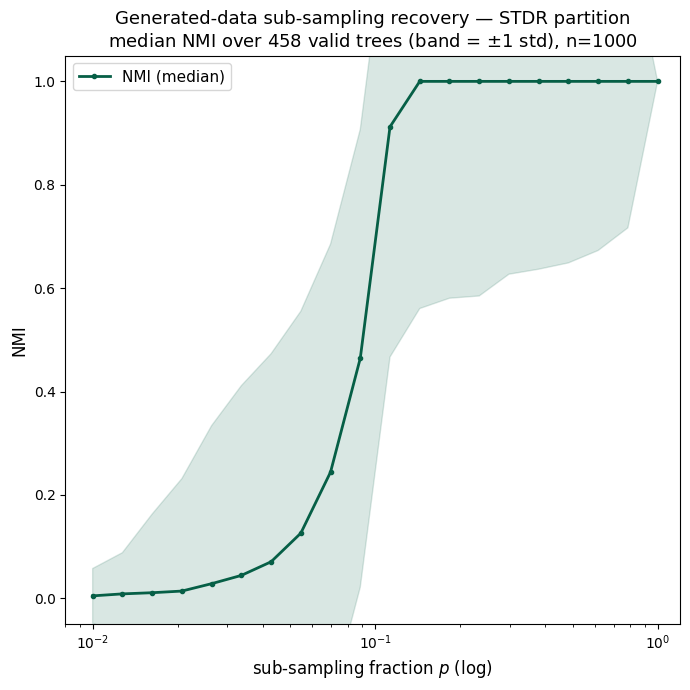

In [23]:
if RUN_SWEEP:
    P = np.array(P_VALUES)
    med = np.nanmedian(nmi, axis=0)
    sd  = np.nanstd(nmi, axis=0)

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.plot(P, med, color='#065f46', lw=2, marker='o', ms=3, label='NMI (median)')
    ax.fill_between(P, med - sd, med + sd, color='#065f46', alpha=0.15)
    ax.set_xscale('log')
    ax.set_xlabel('sub-sampling fraction $p$ (log)', fontsize=12)
    ax.set_ylabel('NMI', fontsize=12)
    ax.set_title(f'Generated-data sub-sampling recovery — STDR partition\n'
                 f'median NMI over {n_valid} valid trees (band = $\\pm$1 std), n={M_TAXA}', fontsize=13)
    ax.set_xlim(P.min() * 0.8, 1.2); ax.set_ylim(-0.05, 1.05); ax.legend(fontsize=11, loc='upper left')
    fig.tight_layout(); plt.show()